## APhys Group Meeting, 20.6.2026

Walk through calculation of Richardson and Froude numbers.

In [1]:
# imports
import ewgreaders as ewg
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
lake = 'Zug'

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

### Data Selection

LZC, P6 from 20.3.2026.

In [3]:
date_ctd = '2026-03-20'
date_m = '2026-04-09'
pl = 'P6'
loc = 'LZC'

di_ctd_sel = di_ctd.query("date == @date_ctd and profile_loc == @pl")
di_m_sel = di_m.query("date == @date_m and location == @loc and sensor == 'adcp'")

C:\Users\herremha\AppData\Local\Temp\ipykernel_28968\4021410945.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_ctd_sel = di_ctd.query("date == @date_ctd and profile_loc == @pl")
C:\Users\herremha\AppData\Local\Temp\ipykernel_28968\4021410945.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date_m and location == @loc and sensor == 'adcp'")


In [4]:
# CTD
p = di_ctd_sel.iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd = ctdreader.load()

# ADCP
all_adcp = []
for _, row in di_m_sel.query("location == @loc").iterrows():
    mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
    deploy, retrieve = mreader.get_deploy_retrieve_dates()
    t_start = deploy + pd.Timedelta(days=1)
    t_end = retrieve - pd.Timedelta(days=1)
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load().sel(time=slice(t_start, t_end))
    ds['depth'] = ds['depth'].round(0)
    ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
ds_adcp = ds_adcp.sortby('depth')
ds_adcp = ds_adcp.groupby('depth').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(77, 87)
full_depth = np.sort(np.concatenate([ds_adcp.depth.values, gap]))
ds_adcp = ds_adcp.reindex(depth=full_depth)

C:\Users\herremha\AppData\Local\Temp\ipykernel_28968\1800780245.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


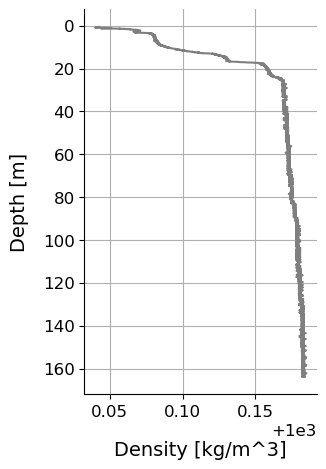

In [5]:
rho = ds_ctd['rho']

fig, ax = plt.subplots(figsize=(3, 5))

sns.lineplot(x=rho, y=rho.depth, orient='y', color='tab:gray', ax=ax)

ax.set_xlabel('Density [kg/m^3]', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.savefig('../../gallery/aphys/2026_05_20/rho.svg', bbox_inches='tight')
plt.show()

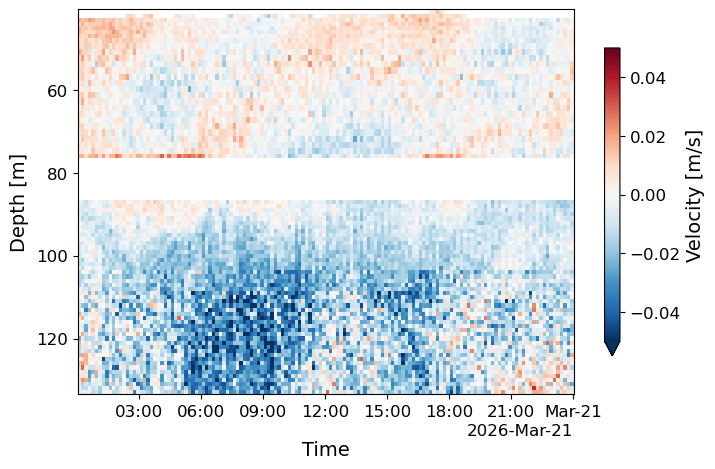

In [6]:
vel = ds_adcp.vel.sel(time=slice(date_ctd, pd.to_datetime(date_ctd)+pd.Timedelta(days=1)))

fig, ax = plt.subplots(figsize=(8, 5))

pc = vel.sel(dir='N').plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8, 'label': 'Velocity [m/s]'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()
plt.savefig('../../gallery/aphys/2026_05_20/vel.svg', bbox_inches='tight')
plt.show()

In [7]:
# only depths with ADCP data
rho = ds_ctd['rho'].sel(depth=slice(ds_adcp.depth.min(), ds_adcp.depth.max()))

# 1-meter rolling average
rho_ra = ewg.signal.rolling_average_z(rho)

# order profile
rho_ra_sort = ewg.signal.order_profile(rho_ra, False, True)

# buoyancy frequency
N2 = ewg.efd.brunt_vaisala_frequency(rho_ra_sort)

# 1-meter binned average    
N2_ba = ewg.signal.binned_average_z(N2)

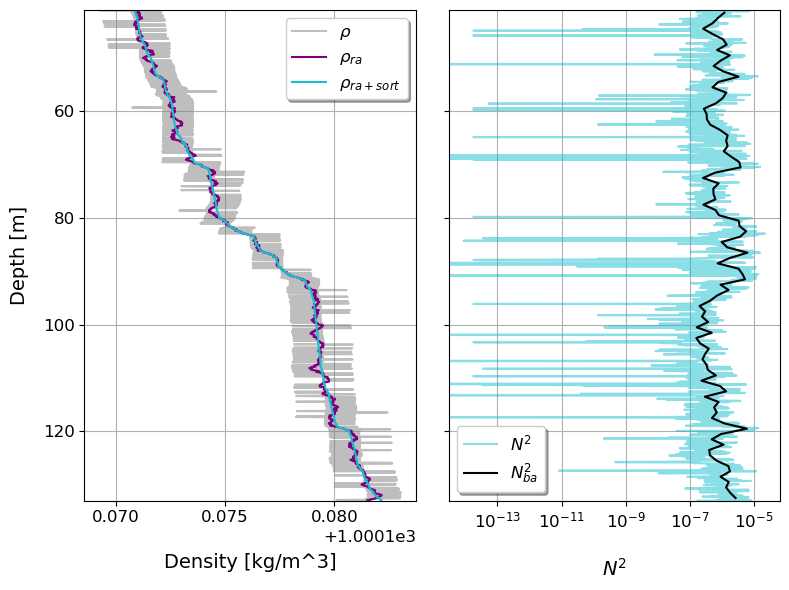

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 6), sharey=True)

# Density
sns.lineplot(x=rho, y=rho.depth, orient='y', color='tab:gray', alpha=0.5, ax=ax[0], label=r'$\rho$')
sns.lineplot(x=rho_ra, y=rho_ra.depth, orient='y', color='purple', ax=ax[0], label=r'$\rho_{ra}$')
sns.lineplot(x=rho_ra_sort, y=rho_ra_sort.depth, orient='y', color='tab:cyan', ax=ax[0], label=r'$\rho_{ra+sort}$')

# Buoyancy frequency
sns.lineplot(x=N2, y=N2.depth, orient='y', color='tab:cyan', alpha=0.5, ax=ax[1], label=r'$N^{2}$')
sns.lineplot(x=N2_ba, y=N2_ba.depth, orient='y', color='black', ax=ax[1], label=r'$N^{2}_{ba}$')


ax[0].set_xlabel('Density [kg/m^3]', fontsize=14, labelpad=20)
ax[1].set_xlabel(r'$N^{2}$', fontsize=14, labelpad=20)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].xaxis.get_offset_text().set_fontsize(12)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].grid(True)
    ax[i].legend(fontsize=12, shadow=True)

ax[1].set_xscale('log')
ax[0].set_ylim(ds_adcp.depth.min(), ds_adcp.depth.max())
ax[0].invert_yaxis()

plt.tight_layout(w_pad=2)
plt.savefig('../../gallery/aphys/2026_05_20/rho_N2.svg', bbox_inches='tight')
plt.show()

In [9]:
# time from CTD
t0 = ds_ctd.time.values[0]
tf = ds_ctd.time.values[-1]
t = t0 + (tf - t0) / 2

# instantaneous
S2 = ewg.efd.vertical_shear(vel.sel(time=t, method='nearest'))

# 5-meter rolling average
S2_ra = ewg.signal.rolling_average_z(S2, ra_window=5)

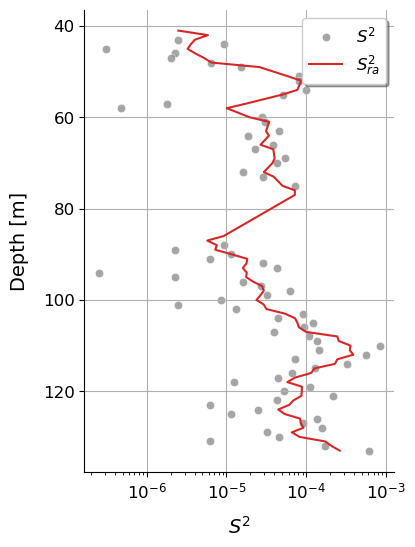

In [10]:
fig, ax = plt.subplots(figsize=(4, 6))

sns.scatterplot(x=S2, y=S2.depth, color='tab:gray', alpha=0.7, ax=ax, label=r'$S^{2}$')

sns.lineplot(x=S2_ra, y=S2_ra.depth, orient='y', color='tab:red', ax=ax, label=r'$S^{2}_{ra}$')
#sns.lineplot(x=S2_tavg, y=S2_tavg.depth, orient='y', ax=ax)

ax.set_xlabel(r'$S^{2}$', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.set_xscale('log')

ax.legend(fontsize=12, shadow=True)

plt.savefig('../../gallery/aphys/2026_05_20/S2.svg', bbox_inches='tight')
plt.show()

In [11]:
# calculate Richardson number
Ri = ewg.efd.gradient_richardson_number(N2_ba, S2_ra)

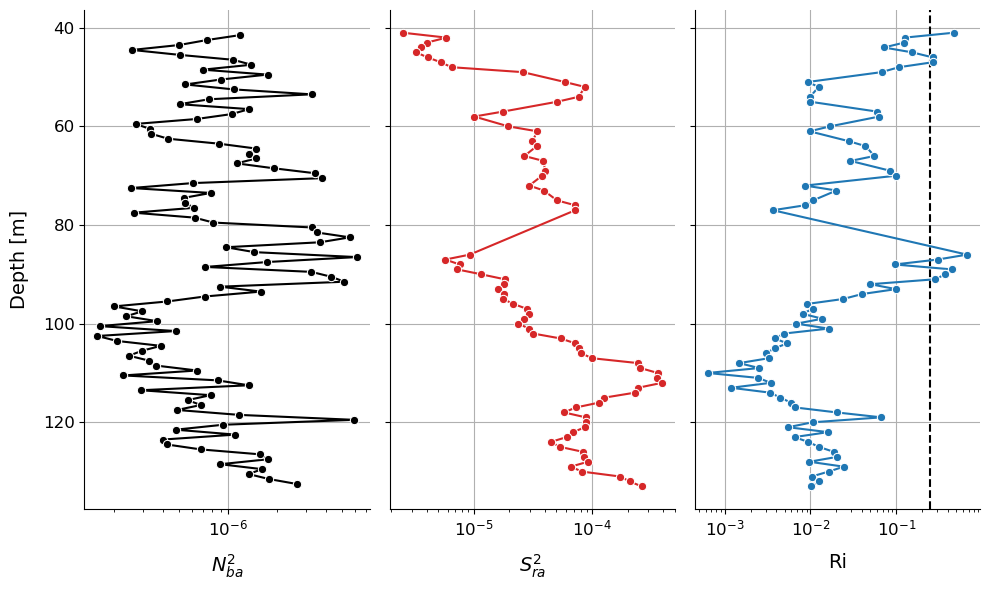

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), sharey=True)

sns.lineplot(x=N2_ba, y=N2_ba.depth, orient='y', color='black', marker='o', ax=ax[0])

sns.lineplot(x=S2_ra, y=S2_ra.depth, orient='y', color='tab:red', marker='o', ax=ax[1])

ax[2].axvline(0.25, color='black', linestyle='--')
sns.lineplot(x=Ri, y=Ri.depth, orient='y', color='tab:blue', marker='o', ax=ax[2])

ax[0].set_xlabel(r'$N^{2}_{ba}$', fontsize=14, labelpad=10)
ax[1].set_xlabel(r'$S^{2}_{ra}$', fontsize=14, labelpad=10)
ax[2].set_xlabel('Ri', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].grid(True)

ax[0].invert_yaxis()

plt.tight_layout()
plt.savefig('../../gallery/aphys/2026_05_20/Ri.svg', bbox_inches='tight')
plt.show()

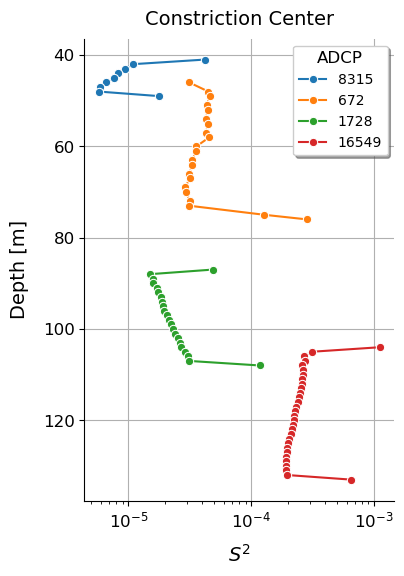

In [17]:
fig, ax = plt.subplots(figsize=(4, 6))

for ds in all_adcp:
    S2_avg = ewg.efd.vertical_shear(ds['vel']).mean(dim='time')
    sns.lineplot(x=S2_avg, y=S2_avg.depth, orient='y', marker='o', ax=ax, label=S2_avg.serial_id.item())

ax.set_xlabel(r'$S^{2}$', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('Constriction Center', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.invert_yaxis()
ax.set_xscale('log')

ax.legend(title='ADCP', fontsize=10, title_fontsize=12, shadow=True)

plt.savefig('../../gallery/aphys/2026_05_20/S2_adcp.svg', bbox_inches='tight')
plt.show()

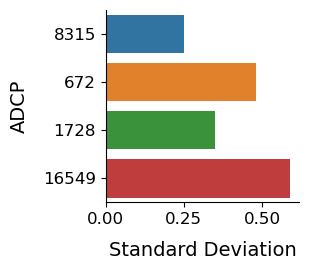

In [41]:
adcp_stdev = pd.DataFrame({
    'serial_id': ['8315', '672', '1728', '16549'],
    'stdev': [0.25, 0.48, 0.35, 0.59]
})

fig, ax = plt.subplots(figsize=(2.5, 2.5))

sns.barplot(adcp_stdev, x='stdev', y='serial_id', orient='y', hue='serial_id', ax=ax)

ax.set_xlabel('Standard Deviation', fontsize=14, labelpad=10)
ax.set_ylabel('ADCP', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../gallery/aphys/2026_05_20/stdev.svg', bbox_inches='tight')
plt.show()

### Richardson Number

#### Load ADCP data

In [3]:
date_m = '2026-04-09'

loc_n = 'LZN'
loc_c = 'LZC'
loc_w = 'LZW'

di_m_sel = di_m.query("date == @date_m and sensor == 'adcp'")

C:\Users\herremha\AppData\Local\Temp\ipykernel_23844\2718559903.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date_m and sensor == 'adcp'")


In [51]:
# LZN
row = di_m_sel.query("location == @loc_n").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_n = areader.load().sel(time=slice(t_start, t_end))

# LZC
all_adcp_c = []
for _, row in di_m_sel.query("location == @loc_c").iterrows():
    mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
    deploy, retrieve = mreader.get_deploy_retrieve_dates()
    t_start = deploy + pd.Timedelta(days=1)
    t_end = retrieve - pd.Timedelta(days=1)
    areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = areader.load().sel(time=slice(t_start, t_end))
    ds['depth'] = ds['depth'].round(0)
    all_adcp_c.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp_c], axis=0).astype('datetime64[ns]'))
all_adcp_c_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp_c]

# concatenate datasets and average common range bins
ds_adcp_c = xr.concat(all_adcp_c_aligned, dim='depth')
ds_adcp_c = ds_adcp_c.sortby('depth')
ds_adcp_c = ds_adcp_c.groupby('depth').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(77, 87)
full_depth = np.sort(np.concatenate([ds_adcp_c.depth.values, gap]))
ds_adcp_c = ds_adcp_c.reindex(depth=full_depth)

# LZW
row = di_m_sel.query("location == @loc_w").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_w = areader.load().sel(time=slice(t_start, t_end))

C:\Users\herremha\AppData\Local\Temp\ipykernel_23844\3474365765.py:27: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp_c = xr.concat(all_adcp_c_aligned, dim='depth')


#### Load CTD data

20.03.2026

In [52]:
date_ctd = '2026-03-20'

pl_n = "P5'"
pl_c = 'P6'
pl_w = 'P6W'

di_ctd_sel = di_ctd.query("date == @date_ctd")

C:\Users\herremha\AppData\Local\Temp\ipykernel_23844\2693315478.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_ctd_sel = di_ctd.query("date == @date_ctd")


In [53]:
# LZN
p = di_ctd_sel.query("profile_loc == @pl_n").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_n = ctdreader.load()

# LZC
p = di_ctd_sel.query("profile_loc == @pl_c").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_c = ctdreader.load()

# LZW
p = di_ctd_sel.query("profile_loc == @pl_w").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_w = ctdreader.load()

##### Calculations + figures

In [54]:
def calculate_richardson_number(ds_ctd, ds_adcp):
    # time from CTD
    t0 = ds_ctd.time.values[0] - pd.Timedelta(minutes=10)
    tf = ds_ctd.time.values[-1] + pd.Timedelta(minutes=10)

    # bin size frm adcp
    bs = ds_adcp.attrs['cell_size']

    # 1-meter rolling average, order profile, calculate buoyancy frequency, 1-meter binned average
    rho = ds_ctd['rho']
    rho_ra = ewg.signal.rolling_average_z(rho)
    rho_ra_sort = ewg.signal.order_profile(rho_ra, False, True)
    N2 = ewg.efd.brunt_vaisala_frequency(rho_ra_sort)
    N2_ba= ewg.signal.binned_average_z(N2, bs)

    # average over time (~30 minutes), calculate shear
    vel = ds_adcp['vel'].sel(time=slice(t0, tf)).mean(dim='time')
    S2 = ewg.efd.vertical_shear(vel)#.mean(dim='time')

    # calculate Richardson number
    Ri = ewg.efd.gradient_richardson_number(N2_ba, S2).sortby('depth')

    return N2, N2_ba, S2, Ri


def plot_N2_S2_Ri(N2_ba_n, S2_n, Ri_n, N2_ba_c, S2_c, Ri_c, N2_ba_w, S2_w, Ri_w, z_min, z_max, save=False, gallery_file=None):

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), sharey=True)

    # N2
    sns.lineplot(x=N2_ba_n, y=N2_ba_n.depth, orient='y', color='tab:pink', marker='o', ax=ax[0], label='N Basin')
    sns.lineplot(x=N2_ba_c, y=N2_ba_c.depth, orient='y', color='tab:blue', marker='o', ax=ax[0], label='C Center')
    sns.lineplot(x=N2_ba_w, y=N2_ba_w.depth, orient='y', color='tab:orange', marker='o', ax=ax[0], label='C West')

    # S2
    sns.lineplot(x=S2_n, y=S2_n.depth, orient='y', color='tab:pink', marker='o', ax=ax[1])
    sns.lineplot(x=S2_c, y=S2_c.depth, orient='y', color='tab:blue', marker='o', ax=ax[1])
    sns.lineplot(x=S2_w, y=S2_w.depth, orient='y', color='tab:orange', marker='o', ax=ax[1])

    # Ri
    ax[2].axhspan(z_min, z_max, color='silver', alpha=0.5)
    ax[2].axvline(0.25, color='black', linestyle='--')
    sns.lineplot(x=Ri_n, y=Ri_n.depth, orient='y', color='tab:pink', marker='o', ax=ax[2])
    sns.lineplot(x=Ri_c, y=Ri_c.depth, orient='y', color='tab:blue', marker='o', ax=ax[2])
    sns.lineplot(x=Ri_w, y=Ri_w.depth, orient='y', color='tab:orange', marker='o', ax=ax[2])

    ax[0].set_xlabel('N2', fontsize=14, labelpad=10)
    ax[1].set_xlabel('S2', fontsize=14, labelpad=10)
    ax[2].set_xlabel('Ri', fontsize=14, labelpad=10)
    ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

    for i in range(len(ax)):
        ax[i].tick_params(axis='both', labelsize=12)
        ax[i].spines[['right', 'top']].set_visible(False)
        ax[i].grid(True)

    ax[0].invert_yaxis()
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    ax[2].set_xscale('log')
    #ax[2].set_xlim(0, 1)

    handles, labels = ax[0].get_legend_handles_labels()
    ax[0].get_legend().remove()
    fig.legend(handles, labels, ncols=3, fontsize=12, shadow=True, loc='upper center', bbox_to_anchor=(0.55, 1.08))

    plt.tight_layout()
    if save:
        plt.savefig(f'../../gallery/aphys/2026_05_20/{gallery_file}.svg', bbox_inches='tight')
    plt.show()


def plot_Ri_zoom(Ri_n, Ri_c, Ri_w, z_min, z_max, save=False, gallery_file=None):
    fig, ax = plt.subplots(figsize=(4, 5))

    ax.axhspan(z_min, z_max, color='silver', alpha=0.5)
    ax.axvline(0.25, color='black', linestyle='--')
    sns.lineplot(x=Ri_n.sel(depth=slice(z_min, z_max)), y=Ri_n.sel(depth=slice(z_min, z_max)).depth, orient='y', color='tab:pink', marker='o', ax=ax)
    sns.lineplot(x=Ri_c.sel(depth=slice(z_min, z_max)), y=Ri_c.sel(depth=slice(z_min, z_max)).depth, orient='y', color='tab:blue', marker='o', ax=ax)
    sns.lineplot(x=Ri_w.sel(depth=slice(z_min, z_max)), y=Ri_w.sel(depth=slice(z_min, z_max)).depth, orient='y', color='tab:orange', marker='o', ax=ax)

    ax.set_xlabel('Ri', fontsize=14, labelpad=10)
    ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xscale('log')
    #ax.set_xlim(0, 1)

    ax.set_ylim(z_min, z_max)
    ax.invert_yaxis()

    if save:
        plt.savefig(f'../../gallery/aphys/2026_05_20/{gallery_file}.svg', bbox_inches='tight')
    plt.show()


In [55]:
# LZN
N2_n, N2_ba_n, S2_n, Ri_n = calculate_richardson_number(ds_ctd_n, ds_adcp_n)

# LZC
N2_c, N2_ba_c, S2_c, Ri_c = calculate_richardson_number(ds_ctd_c, ds_adcp_c)

# LZW
N2_w, N2_ba_w, S2_w, Ri_w = calculate_richardson_number(ds_ctd_w, ds_adcp_w)

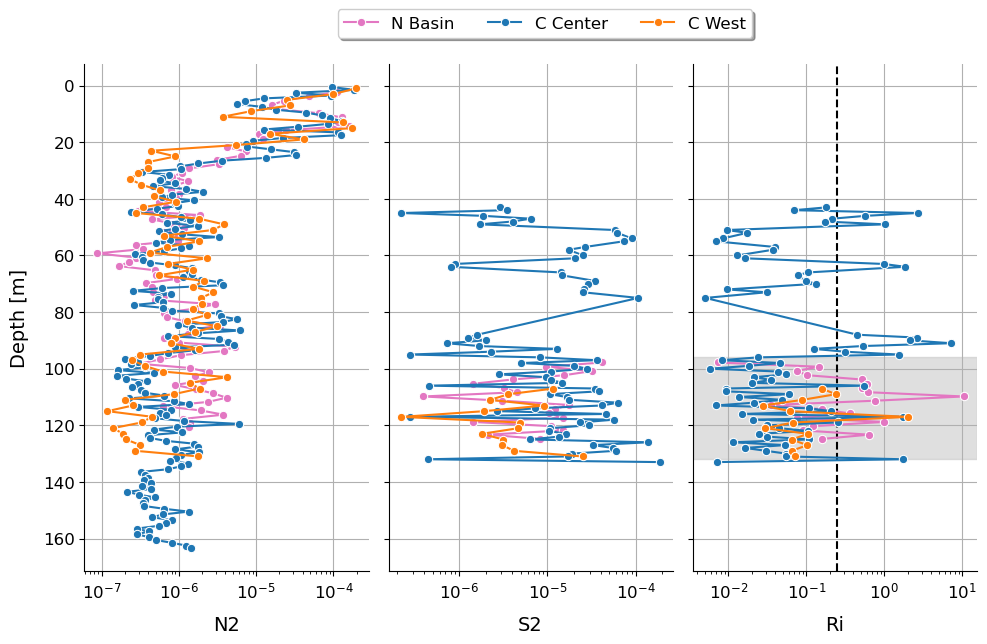

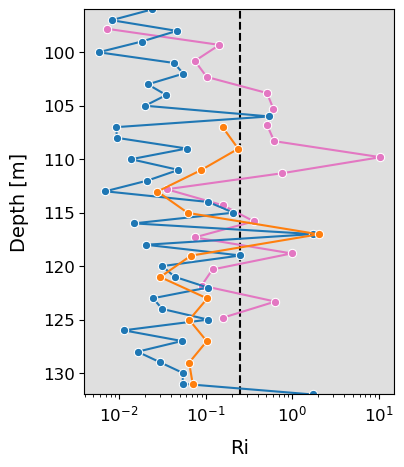

In [56]:
# common depth range
z_min = 96
z_max = 132

plot_N2_S2_Ri(N2_ba_n, S2_n, Ri_n, N2_ba_c, S2_c, Ri_c, N2_ba_w, S2_w, Ri_w, z_min, z_max)
plot_Ri_zoom(Ri_n, Ri_c, Ri_w, z_min, z_max)

#### Load CTD data

27.03.2026

In [71]:
date_ctd = '2026-03-27'

pl_n = "P5'"
pl_c = 'VMPC'
pl_w = 'P6W'

di_ctd_sel = di_ctd.query("date == @date_ctd")

C:\Users\herremha\AppData\Local\Temp\ipykernel_23844\3432717335.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_ctd_sel = di_ctd.query("date == @date_ctd")


In [72]:
# LZN
p = di_ctd_sel.query("profile_loc == @pl_n").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_n = ctdreader.load()

# LZC
p = di_ctd_sel.query("profile_loc == @pl_c").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_c = ctdreader.load()

# LZW
p = di_ctd_sel.query("profile_loc == @pl_w").iloc[0]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds_ctd_w = ctdreader.load()

##### Calculations + figures

In [73]:
# LZN
N2_n, N2_ba_n, S2_n, Ri_n = calculate_richardson_number(ds_ctd_n, ds_adcp_n)

# LZC
N2_c, N2_ba_c, S2_c, Ri_c = calculate_richardson_number(ds_ctd_c, ds_adcp_c)

# LZW
N2_w, N2_ba_w, S2_w, Ri_w = calculate_richardson_number(ds_ctd_w, ds_adcp_w)

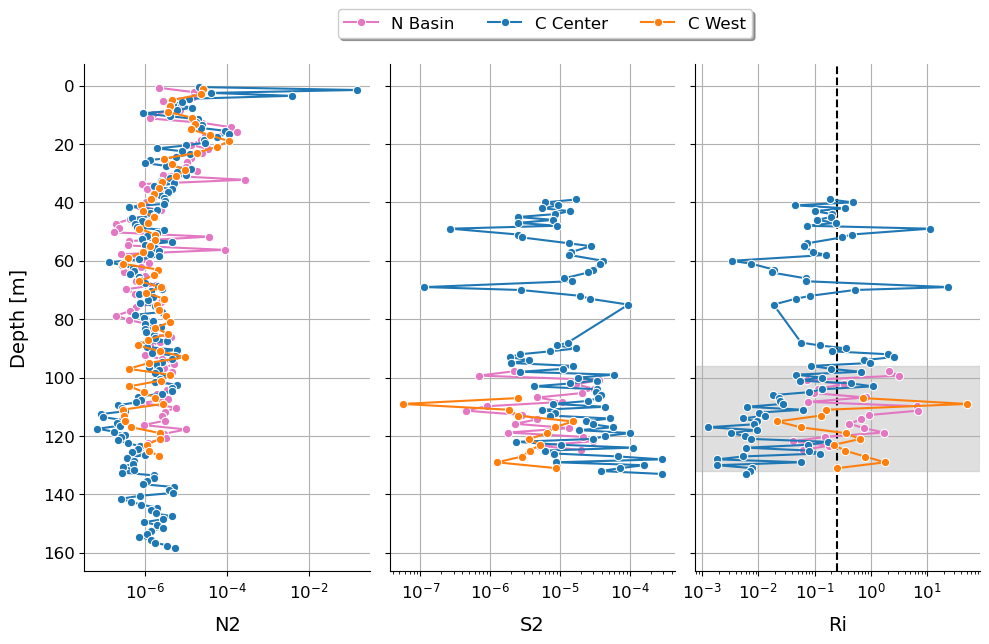

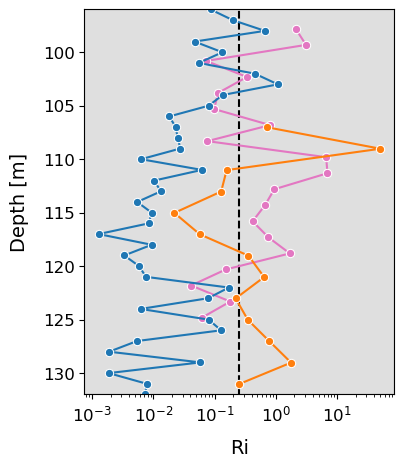

In [74]:
# common depth range
z_min = 96
z_max = 132

plot_N2_S2_Ri(N2_ba_n, S2_n, Ri_n, N2_ba_c, S2_c, Ri_c, N2_ba_w, S2_w, Ri_w, z_min, z_max)
plot_Ri_zoom(Ri_n, Ri_c, Ri_w, z_min, z_max)

#### Shear dependence on ADCP

In [99]:
all_S2 = []
for ds in all_adcp_c:
    #ds = ewg.signal.valid_depths(ds, 0.9)
    S2 = ewg.efd.vertical_shear(ds['vel'])
    all_S2.append(S2)

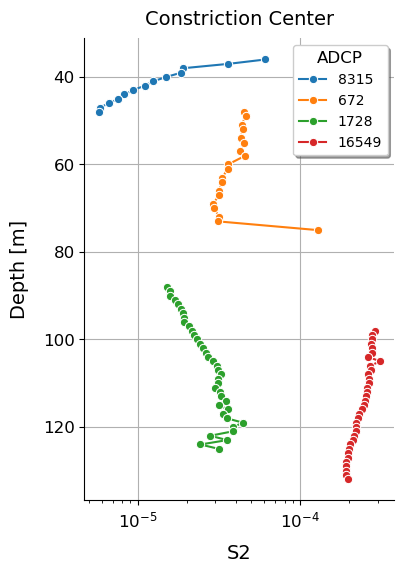

In [109]:
fig, ax = plt.subplots(figsize=(4, 6))

for S2 in all_S2:
    S2_avg = S2.isel(depth=slice(1, -1)).mean(dim='time')
    sns.lineplot(x=S2_avg, y=S2_avg.depth, orient='y', marker='o', ax=ax, label=S2_avg.serial_id.item())

ax.set_xlabel('S2', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('Constriction Center', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.invert_yaxis()
ax.set_xscale('log')

ax.legend(title='ADCP', fontsize=10, title_fontsize=12, shadow=True)

plt.show()

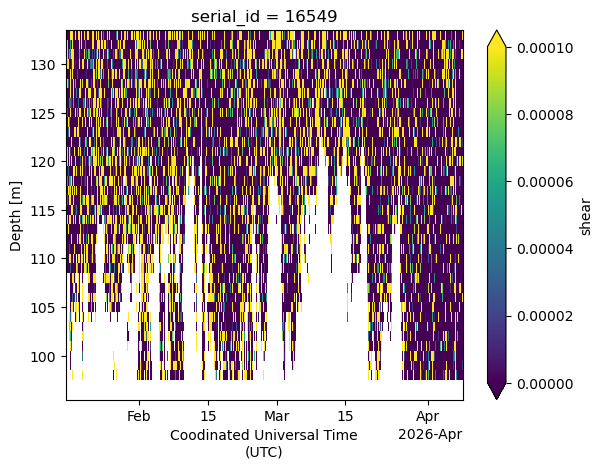

In [107]:
(S2 - S2.mean('time')).plot(vmin=0, vmax=0.0001)

#### Ri timeseries

Take N2~O(-6) for hypolimnion.


In [75]:
N2 = 1e-6

In [76]:
vel = ds_adcp_c['vel']
S2 = ewg.efd.vertical_shear(vel) 

In [77]:
Ri = (N2 / S2).rename('Ri')

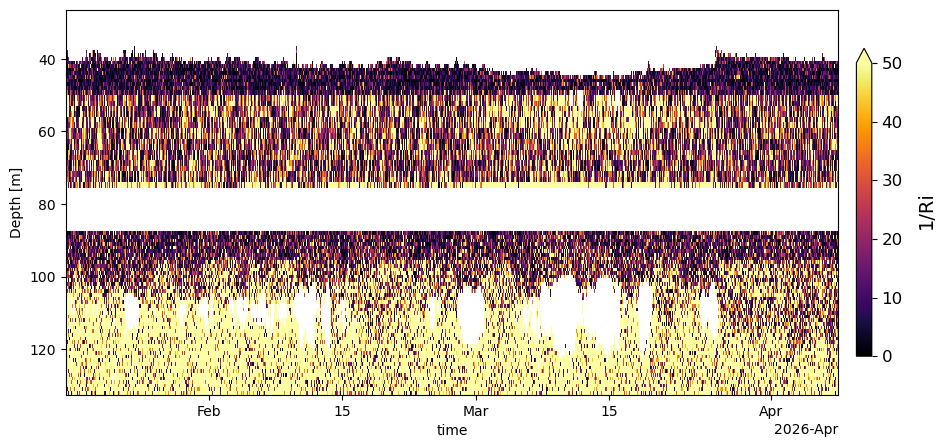

In [78]:
fig, ax = plt.subplots(figsize=(12, 5))

im = (1/Ri.isel(depth=slice(1, -1))).plot(x='time', y='depth', cmap='inferno', vmax=50, ax=ax, cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, rasterized=True)
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('1/Ri', fontsize=14, labelpad=10)

ax.invert_yaxis()

plt.show()

### Workspace

In [2]:
lake = 'Zug'
year = '2026'
date = '20260409'

In [3]:
di = ewg.get_data_index('Zug', 'ctd')
di

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
0,Zug,2024-11-08,10:42,P9,680173,217479,sea&sun,1807,IB081320_2
1,Zug,2024-11-08,11:02,P7,680083,218327,sea&sun,1807,IB081320_3
2,Zug,2024-11-08,11:20,P6W,679942,218820,sea&sun,1807,IB081320_4
3,Zug,2024-11-08,11:34,P6,680090,218816,sea&sun,1807,IB081320_5
4,Zug,2024-11-08,11:52,P5'',679841,219294,sea&sun,1807,IB081320_6
...,...,...,...,...,...,...,...,...,...
283,Zug,2026-04-09,14:31,P6W,679931,218791,sea&sun,2023,K4101445_6
284,Zug,2026-04-09,14:54,P10,680813,216240,sea&sun,2023,K4101445_7
285,Zug,2026-04-10,10:19,P6E,680288,218845,sea&sun,2023,K4101445_8
286,Zug,2026-04-10,11:14,P6W,679912,218786,sea&sun,2023,K4101445_9


In [17]:
def load_thermistor_chain(lake, year, date, loc):
    mreader = ewg.mooring_reader.MooringReader(lake, year, date, loc)
    t_start = mreader.deploy + pd.Timedelta(days=1)
    t_end = mreader.retrieve - pd.Timedelta(days=1)
    thermistors = mreader.get_thermistors()

    all_ds = []
    for t in thermistors:
        if t['serial_id'] != '082133':
            try:
                treader = ewg.thermistor_reader.ThermistorReader(lake, year, date, loc, t['serial_id'])
                ds = treader.load()
                ds = ds.sel(time=slice(t_start, t_end))
                all_ds.append(ds)
            except FileNotFoundError:
                continue

    ds_temp = mreader.create_instrument_chain(all_ds)

    return ds_temp


def load_oxygen_logger_chain(lake, year, date, loc):
    mreader = ewg.mooring_reader.MooringReader(lake, year, date, loc)
    t_start = mreader.deploy + pd.Timedelta(days=1)
    t_end = mreader.retrieve - pd.Timedelta(days=1)
    oxygen_loggers = mreader.get_oxygen_loggers()

    all_ds = []
    for ol in oxygen_loggers:
        try:
            oreader = ewg.o2_reader.O2Reader(lake, year, date, loc, ol['serial_id'])
            ds = oreader.load()
            ds = ds.sel(time=slice(t_start, t_end))
            
            # anoxic region
            if ds['depth'] > 100:
                ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()
            
            all_ds.append(ds)
        except FileNotFoundError:
            continue

    ds_do = mreader.create_instrument_chain(all_ds)

    return ds_do


def load_adcp(lake, year, date, loc):
    mreader = ewg.mooring_reader.MooringReader(lake, date, loc)
    t_start = mreader.deploy + pd.Timedelta(days=1)
    t_end = mreader.retrieve - pd.Timedelta(days=1)
    adcp = mreader.get_adcps()[-1]
    areader = ewg.adcp_reader.ADCPReader(lake, date, loc, adcp['serial_id'])
    ds = areader.load()
    ds = ds.sel(time=slice(t_start, t_end))

    return ds

In [4]:
ds_temp_w = load_thermistor_chain(lake, year, date, 'LZW')
ds_temp_c = load_thermistor_chain(lake, year, date, 'LZC')
ds_temp_e = load_thermistor_chain(lake, year, date, 'LZE')

ds_do_w = load_oxygen_logger_chain(lake, year, date, 'LZW')
ds_do_c = load_oxygen_logger_chain(lake, year, date, 'LZC')
ds_do_e = load_oxygen_logger_chain(lake, year, date, 'LZE')

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:231: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:231: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_alig

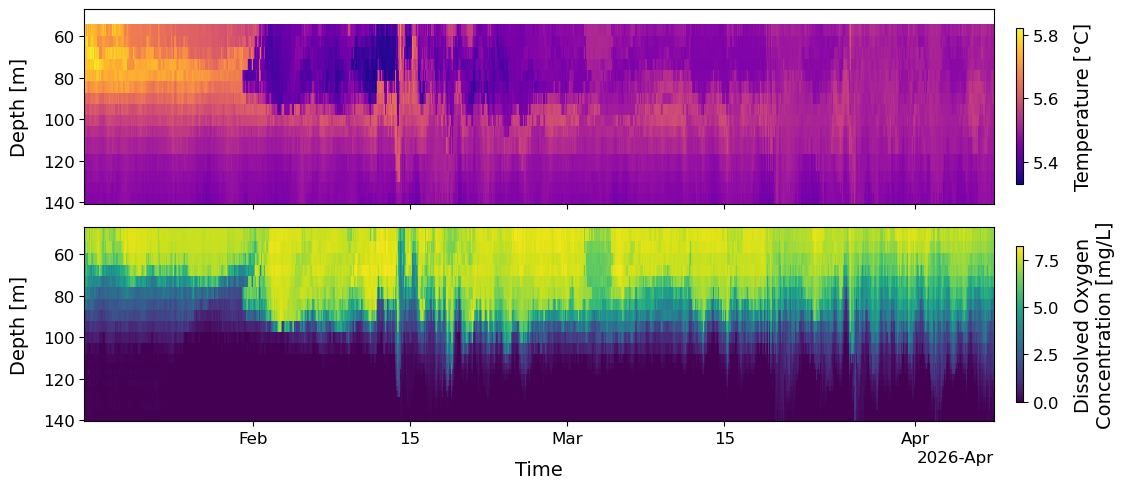

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True, sharey=True)

im_t = ds_temp_c.temp.plot(x='time', y='depth', cmap='plasma', ax=ax[0], cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, rasterized=True)
im_t.colorbar.ax.tick_params(labelsize=12)
im_t.colorbar.ax.set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)

im_do = ds_do_c.do2_conc.plot(x='time', y='depth', cmap='viridis', ax=ax[1], cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, rasterized=True)
im_do.colorbar.ax.tick_params(labelsize=12)
im_do.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=14, labelpad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)


ax[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
def plot_temp_do(ds_temp, ds_do, t0, tf, z_min, z_max):
    # data selection
    ds_temp_sel = ds_temp.sel(time=slice(t0, tf), depth=slice(z_min, z_max))
    ds_do_sel = ds_do.sel(time=slice(t0, tf), depth=slice(z_min, z_max))

    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True, sharey=True)

    im_t = ds_temp_sel.temp.plot(x='time', y='depth', cmap='plasma', ax=ax[0], cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, rasterized=True)
    im_t.colorbar.ax.tick_params(labelsize=12)
    im_t.colorbar.ax.set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)

    im_do = ds_do_sel.do2_conc.plot(x='time', y='depth', cmap='viridis', ax=ax[1], cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, rasterized=True)
    im_do.colorbar.ax.tick_params(labelsize=12)
    im_do.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=14, labelpad=10)
    ax[1].xaxis.get_offset_text().set_fontsize(12)

    ax[0].set_xlabel('')
    ax[1].set_xlabel('Time', fontsize=14, labelpad=10)

    for i in range(len(ax)):
        ax[i].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
        ax[i].tick_params(axis='both', labelsize=12)


    ax[0].invert_yaxis()

    plt.tight_layout()
    plt.show()

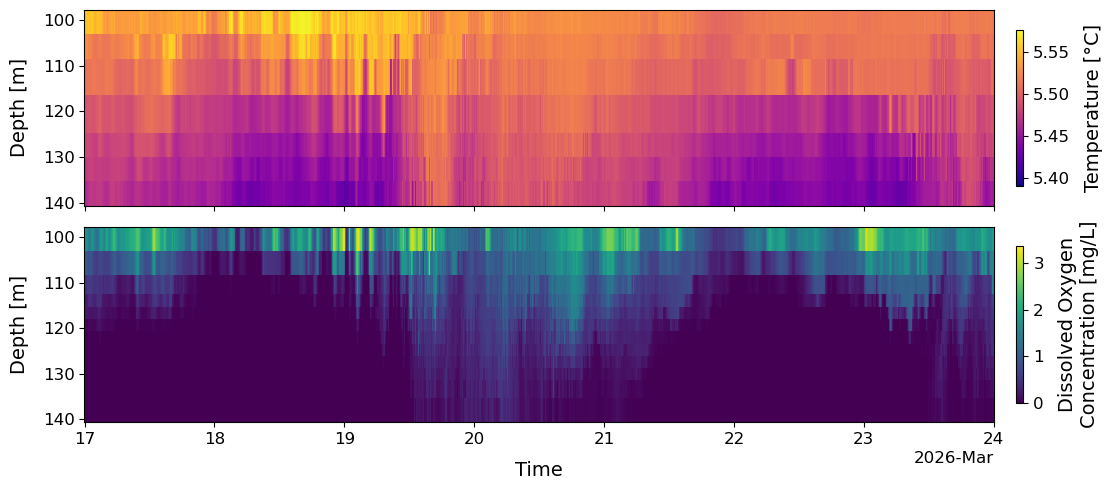

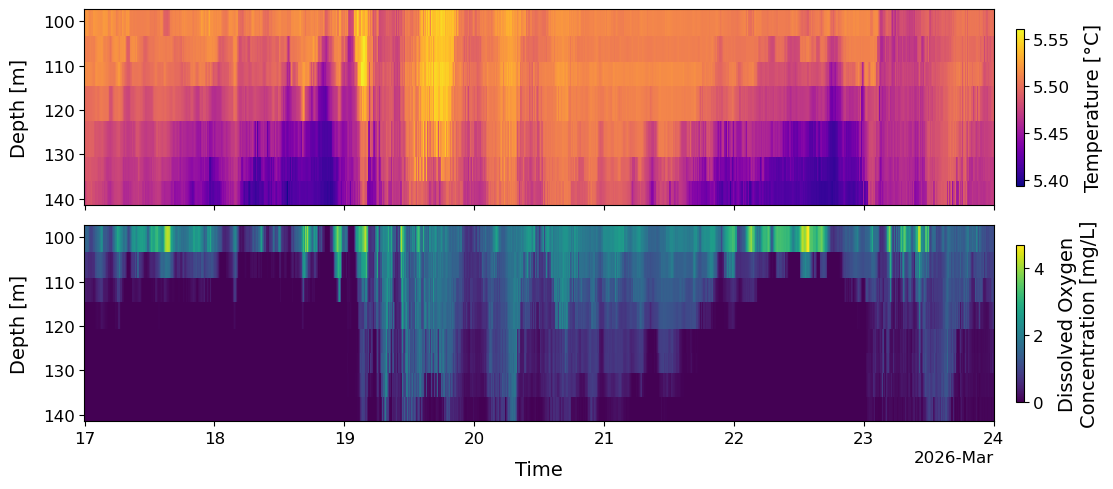

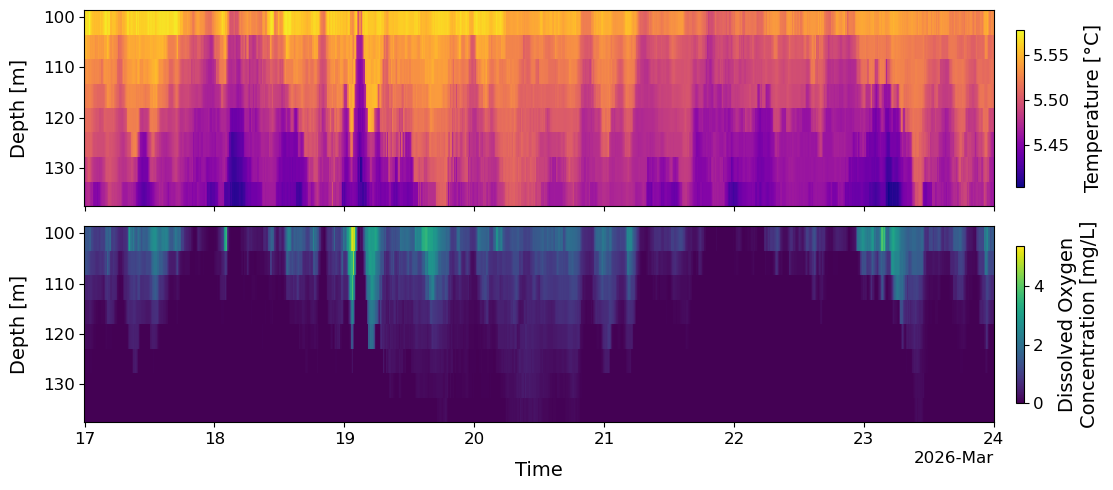

In [16]:
t0 = '2026-03-17'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_temp_do(ds_temp_c, ds_do_c, t0, tf, 100, None)
plot_temp_do(ds_temp_w, ds_do_w, t0, tf, 100, None)
plot_temp_do(ds_temp_e, ds_do_e, t0, tf, 100, None)

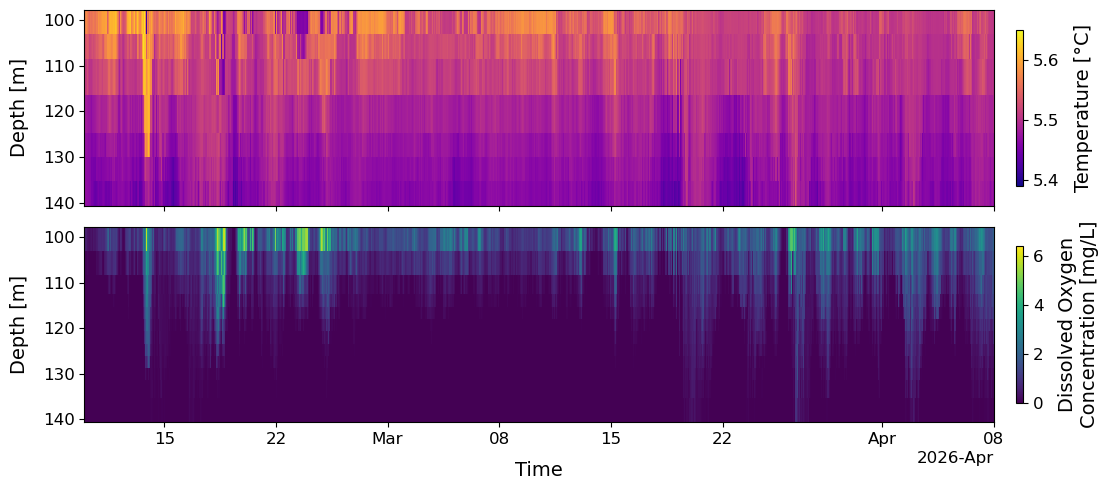

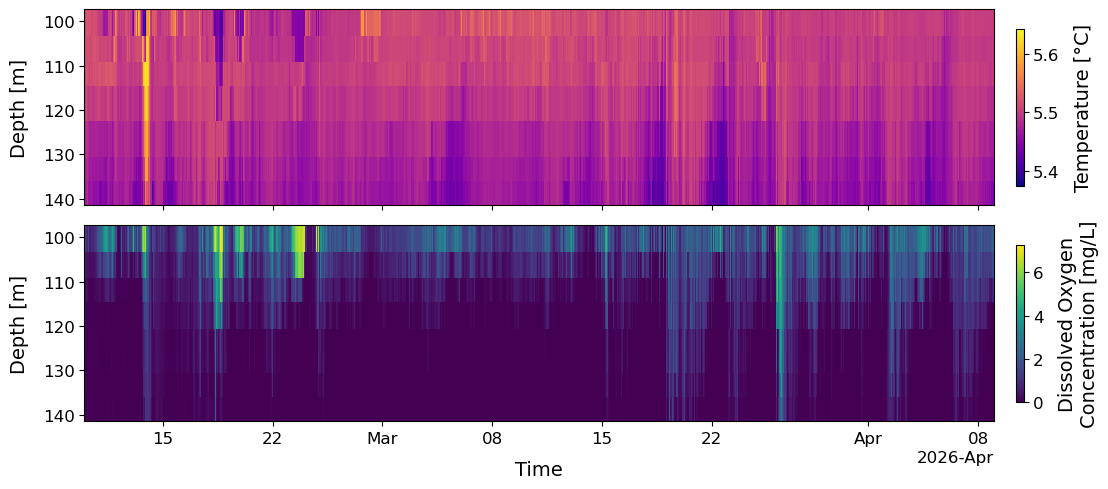

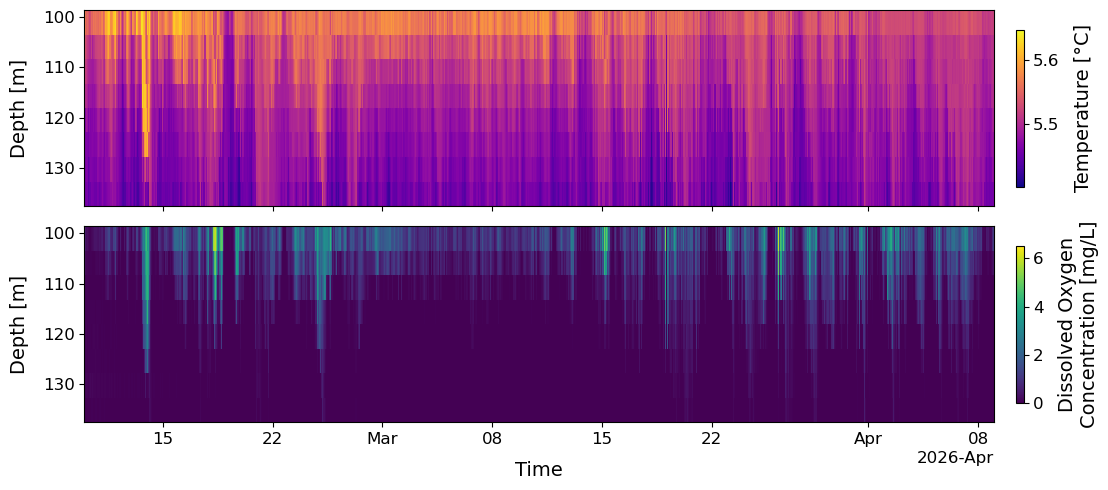

In [18]:
t0 = '2026-02-10'
tf = None

plot_temp_do(ds_temp_c, ds_do_c, t0, tf, 100, None)
plot_temp_do(ds_temp_w, ds_do_w, t0, tf, 100, None)
plot_temp_do(ds_temp_e, ds_do_e, t0, tf, 100, None)

### Correlation oxygen and temperature time series spatial variability

Compare same depth, LZW v. LZC v. LZE.

In [114]:
date = '2026-03-19'
profile_loc = 'P6'

di = ewg.get_data_index(lake, 'ctd')
di

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
0,Zug,2024-01-11,14:12,VMPS,680461,216988,sea&sun,189,I1190802_2
1,Zug,2024-01-11,14:24,P8',680159,217784,sea&sun,189,I1190802_3
2,Zug,2024-01-11,14:39,PC,680127,218654,sea&sun,189,I1190802_4
3,Zug,2024-01-11,15:02,P4',679373,220121,sea&sun,189,I1190802_5
4,Zug,2024-04-03,10:30,P10',680461,216440,sea&sun,281,20240403_Dave_Zug_2_1
...,...,...,...,...,...,...,...,...,...
338,Zug,2026-04-09,14:19,P6E,680267,218863,sea&sun,2023,K4101445_4
339,Zug,2026-04-09,14:31,P6W,679931,218791,sea&sun,2023,K4101445_6
340,Zug,2026-04-09,14:54,P10,680813,216240,sea&sun,2023,K4101445_7
341,Zug,2026-04-10,10:19,P6E,680288,218845,sea&sun,2023,K4101445_8


In [116]:
di_sel = di.query("date == @date and profile_loc == @profile_loc")
di_sel

C:\Users\herremha\AppData\Local\Temp\ipykernel_14640\2056531416.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_sel = di.query("date == @date and profile_loc == @profile_loc")


,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
294,Zug,2026-03-19,12:55,P6,680023,218909,sea&sun,2023,K3191620_3
295,Zug,2026-03-19,13:09,P6,680045,218861,sea&sun,2023,K3191620_4


In [139]:
p = di_sel.iloc[-1]

In [140]:
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds = ctdreader.load()

In [145]:
ds_do = ds_do_c.sel(time=ds.time.values[0] - pd.Timedelta(hours=1), method='nearest')
ds_temp = ds_temp_c.sel(time=ds.time.values[0] - pd.Timedelta(hours=1), method='nearest')

In [143]:
err = 0.3

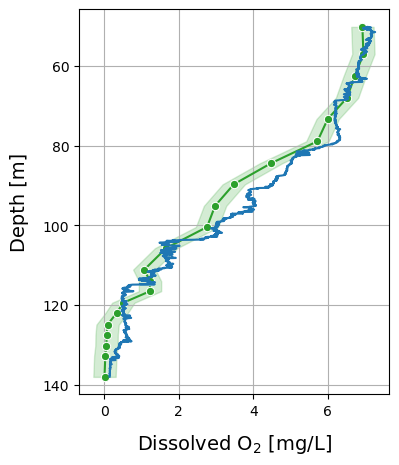

In [144]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.lineplot(x=ds_do.do2_conc, y=ds_do.depth, orient='y', color='tab:green', marker='o', ax=ax)
#ax.errorbar(x=ds_sel.do2_conc, y=ds_sel.depth, xerr=err, 
#            fmt='none', ecolor='tab:green', elinewidth=None, capsize=0)
ax.fill_betweenx(ds_do.depth, 
                 ds_do.do2_conc - err, 
                 ds_do.do2_conc + err, 
                 color='tab:green', alpha=0.2)

sns.lineplot(x=ds.sel(depth=slice(ds_do.depth.min(), ds_do.depth.max())).do2_conc, y=ds.sel(depth=slice(ds_do.depth.min(), ds_do.depth.max())).depth, orient='y', ax=ax)



ax.set_xlabel(r'Dissolved O$_{2}$ [mg/L]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.grid(True)

plt.show()

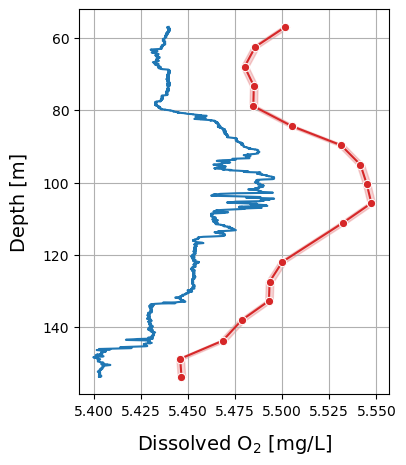

In [146]:
err = 0.002

fig, ax = plt.subplots(figsize=(4, 5))

sns.lineplot(x=ds_temp.temp, y=ds_temp.depth, orient='y', color='tab:red', marker='o', ax=ax)
#ax.errorbar(x=ds_sel.do2_conc, y=ds_sel.depth, xerr=err, 
#            fmt='none', ecolor='tab:green', elinewidth=None, capsize=0)
ax.fill_betweenx(ds_temp.depth, 
                 ds_temp.temp - err, 
                 ds_temp.temp + err, 
                 color='tab:red', alpha=0.2)

sns.lineplot(x=ds.sel(depth=slice(ds_temp.depth.min(), ds_temp.depth.max())).temp, y=ds.sel(depth=slice(ds_temp.depth.min(), ds_temp.depth.max())).depth, orient='y', ax=ax)



ax.set_xlabel(r'Dissolved O$_{2}$ [mg/L]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.grid(True)

plt.show()

In [72]:
da_sel

<xarray.Dataset> Size: 1kB
Dimensions:    (depth: 21)
Coordinates:
    time       datetime64[ns] 8B 2026-01-17T16:40:00
  * depth      (depth) float64 168B 50.2 57.0 62.5 68.0 ... 130.2 132.7 138.0
    serial_id  (depth) <U6 504B '471917' '448315' '091560' ... '295985' '007431'
Data variables:
    temp       (depth) float64 168B 5.766 5.752 5.782 5.82 ... 5.448 5.502 5.448
    do2_conc   (depth) float64 168B 7.251 7.157 5.615 ... 0.049 0.062 0.035
    do2_sat    (depth) float64 168B 60.88 60.07 47.17 ... 1.258 0.8507 0.9661
Attributes:
    location:     LZC
    xsc:          680091
    ysc:          218814
    lake_depth:   177
    bathy_depth:  177.53
    deployment:   16.01.2026
    retrieval:    09.04.2026
    sensor:       minidot
    serial_id:    471917
    depth:        50.2
    t_offset:     None

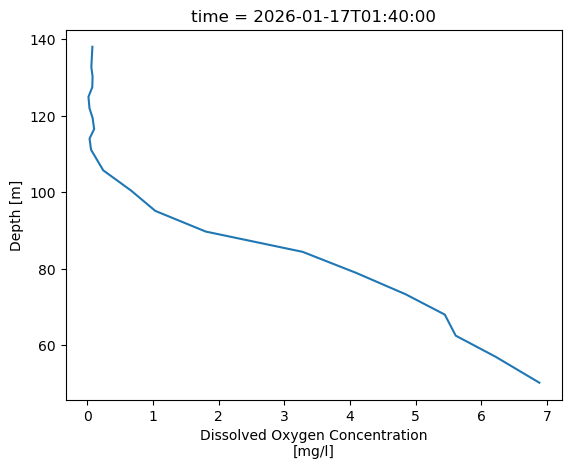

In [70]:
ds_do_c.isel(time=100).do2_conc.plot(y='depth')

In [59]:
ds_do_w.isel(time=0).do2_conc

<xarray.DataArray 'do2_conc' (depth: 8)> Size: 64B
array([0.033, 0.067, 0.028, 0.019, 0.026, 0.107, 0.025, 0.043])
Coordinates:
    time       datetime64[ns] 8B 2026-02-06
  * depth      (depth) float64 64B 100.3 106.4 111.8 117.2 ... 128.0 133.4 138.8
    serial_id  (depth) <U6 192B '030741' '242020' '618773' ... '117137' '587731'

In [30]:
ds_do_w.depth

<xarray.DataArray 'depth' (depth: 8)> Size: 64B
array([100.3, 106.4, 111.8, 117.2, 124.2, 128. , 133.4, 138.8])
Coordinates:
  * depth      (depth) float64 64B 100.3 106.4 111.8 117.2 ... 128.0 133.4 138.8
    serial_id  (depth) <U6 192B '030741' '242020' '618773' ... '117137' '587731'
Attributes:
    units:      m
    long_name:  Depth

In [31]:
ds_do_c.depth

<xarray.DataArray 'depth' (depth: 21)> Size: 168B
array([ 50.2,  57. ,  62.5,  68. ,  73.3,  78.9,  84.4,  89.7,  95.1, 100.4,
       105.7, 111.1, 114. , 116.5, 119.4, 121.9, 124.9, 127.4, 130.2, 132.7,
       138. ])
Coordinates:
  * depth      (depth) float64 168B 50.2 57.0 62.5 68.0 ... 130.2 132.7 138.0
    serial_id  (depth) <U6 504B '471917' '448315' '091560' ... '295985' '007431'
Attributes:
    units:      m
    long_name:  Depth

In [32]:
ds_do_e.depth

<xarray.DataArray 'depth' (depth: 8)> Size: 64B
array([101. , 105.9, 110.8, 115.6, 120.5, 125.4, 130.3, 135.2])
Coordinates:
  * depth      (depth) float64 64B 101.0 105.9 110.8 115.6 ... 125.4 130.3 135.2
    serial_id  (depth) <U6 192B '564167' '158991' '008271' ... '014343' '246068'
Attributes:
    units:      m
    long_name:  Depth

In [43]:
d = 125
t0 = ds_do_w.time.values[0]
tf = ds_do_c.time.values[-1]
da_do_w = ds_do_w.sel(depth=d, method='nearest').sel(time=slice(t0, tf)).do2_conc
da_do_c = ds_do_c.sel(depth=d, method='nearest').sel(time=slice(t0, tf)).do2_conc
da_do_e = ds_do_e.sel(depth=d, method='nearest').sel(time=slice(t0, tf)).do2_conc

da_do_w.depth.item(), da_do_c.depth.item(), da_do_e.depth.item()

(124.2, 124.9, 125.4)

<Axes: xlabel='do2_conc', ylabel='do2_conc'>

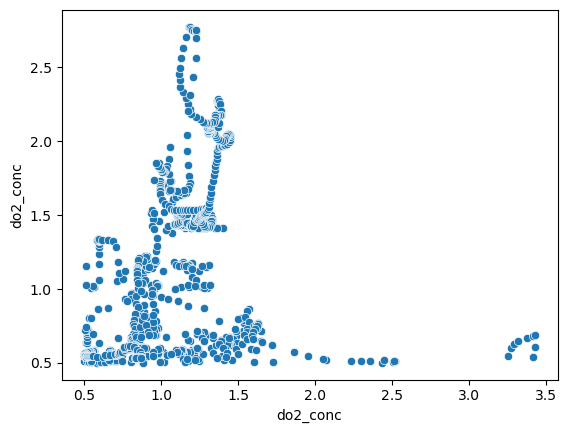

In [54]:
mask = (da_do_w > 0.5) & (da_do_e > 0.5)
sns.scatterplot(x=da_do_w[mask], y=da_do_e[mask])

<Axes: xlabel='do2_conc', ylabel='do2_conc'>

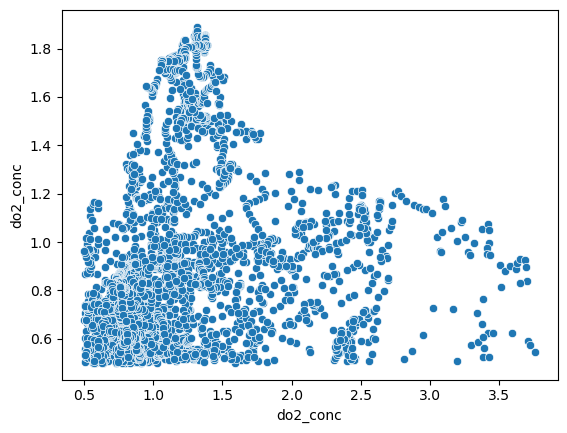

In [55]:
mask = (da_do_w > 0.5) & (da_do_c > 0.5)
sns.scatterplot(x=da_do_w[mask], y=da_do_c[mask])

In [37]:
scipy.stats.pearsonr(ds_do_w.sel(depth=100, method='nearest').do2_conc, ds_do_w.sel(depth=140, method='nearest').do2_conc)

PearsonRResult(statistic=np.float64(0.20253176905009126), pvalue=np.float64(0.0))

In [38]:
scipy.stats.pearsonr(ds_do_c.sel(depth=100, method='nearest').do2_conc, ds_do_c.sel(depth=140, method='nearest').do2_conc)

PearsonRResult(statistic=np.float64(0.0922827494440676), pvalue=np.float64(6.091673439514524e-219))

In [42]:
scipy.stats.pearsonr(ds_do_c.sel(depth=80, method='nearest').do2_conc, ds_do_c.sel(depth=120, method='nearest').do2_conc)

PearsonRResult(statistic=np.float64(0.012101586055831448), pvalue=np.float64(3.5785481004129854e-05))

In [39]:
scipy.stats.pearsonr(ds_do_e.sel(depth=100, method='nearest').do2_conc, ds_do_e.sel(depth=140, method='nearest').do2_conc)

PearsonRResult(statistic=np.float64(0.05366328374274241), pvalue=np.float64(6.1080090223001986e-58))

In [28]:
scipy.stats.pearsonr(da_do_w, da_do_c), scipy.stats.pearsonr(da_do_c, da_do_e), scipy.stats.pearsonr(da_do_w, da_do_e)

(PearsonRResult(statistic=np.float64(0.6199935708907865), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.6027941447485088), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.3222238316419623), pvalue=np.float64(0.0)))

### Correlation oxygen and temperature time series

In [70]:
d = 100
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [71]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(-0.5200569325600025), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(-0.3672979066164856), pvalue=np.float64(0.0)))

In [72]:
d = 135
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [73]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(0.4060024048676202), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.40315578517679906), pvalue=np.float64(0.0)))

In [74]:
d = 80
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [75]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(-0.8975687946484098), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(-0.9010916809146399), pvalue=np.float64(0.0)))

In [78]:
d = 57
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [79]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(-0.35947766360742517), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(-0.46273454784985063), pvalue=np.float64(0.0)))

In [80]:
d = 125
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [81]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(0.6310375170319112), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.6422732347233718), pvalue=np.float64(0.0)))

In [82]:
d = 115
da_temp = ds_temp_c.sel(depth=d, method='nearest').temp
da_do = ds_do_c.sel(depth=d, method='nearest').do2_conc

da_temp_downsamp = da_temp.resample(time='1min').mean()

# z-score
z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

# detrend
detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

In [83]:
scipy.stats.pearsonr(da_temp_downsamp, da_do), scipy.stats.pearsonr(detrend_temp, detrend_do)

(PearsonRResult(statistic=np.float64(0.18583254024055207), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.2642995595748215), pvalue=np.float64(0.0)))

In [85]:
ds_temp_c

<xarray.Dataset> Size: 106MB
Dimensions:    (depth: 18, time: 699841)
Coordinates:
  * time       (time) datetime64[ns] 6MB 2026-01-17 ... 2026-04-08
  * depth      (depth) float64 144B 57.0 62.5 68.0 73.3 ... 143.7 148.7 153.7
    serial_id  (depth) <U6 432B '200566' '205518' '200569' ... '205536' '205517'
Data variables:
    temp       (depth, time) float64 101MB 5.794 5.791 5.787 ... 5.43 5.43 5.432
Attributes:
    location:     LZC
    xsc:          680091
    ysc:          218814
    lake_depth:   177
    bathy_depth:  177.53
    deployment:   16.01.2026
    retrieval:    09.04.2026
    sensor:       rbr_temp
    serial_id:    200566
    depth:        57.0
    t_offset:     None

In [86]:
ds_do_c

<xarray.Dataset> Size: 60MB
Dimensions:    (depth: 21, time: 116641)
Coordinates:
  * time       (time) datetime64[ns] 933kB 2026-01-17 ... 2026-04-08
  * depth      (depth) float64 168B 50.2 57.0 62.5 68.0 ... 130.2 132.7 138.0
    serial_id  (depth) <U6 504B '471917' '448315' '091560' ... '295985' '007431'
Data variables:
    temp       (depth, time) float64 20MB 5.776 5.786 5.796 ... 5.448 5.448
    do2_conc   (depth, time) float64 20MB 7.206 7.188 7.171 ... 0.006 0.006
    do2_sat    (depth, time) float64 20MB 60.52 60.39 60.26 ... 0.7246 0.7246
Attributes:
    location:     LZC
    xsc:          680091
    ysc:          218814
    lake_depth:   177
    bathy_depth:  177.53
    deployment:   16.01.2026
    retrieval:    09.04.2026
    sensor:       minidot
    serial_id:    471917
    depth:        50.2
    t_offset:     None

In [123]:
res = []
for d in tqdm(ds_do_c.depth.values):
    if d in ds_temp_c.depth:
        da_temp = ds_temp_c.sel(depth=d).temp
        da_do = ds_do_c.sel(depth=d).do2_conc

        da_temp_downsamp = da_temp.resample(time='1min').mean()

        # z-score
        z_temp = (da_temp_downsamp - da_temp_downsamp.mean()) / da_temp_downsamp.std(ddof=1)
        z_do = (da_do - da_do.mean()) / da_do.std(ddof=1)

        # detrend
        detrend_temp = xr.DataArray(scipy.signal.detrend(da_temp_downsamp), coords=da_temp_downsamp.coords, dims=da_temp_downsamp.dims, name=da_temp_downsamp.name)
        detrend_do = xr.DataArray(scipy.signal.detrend(da_do), coords=da_do.coords, dims=da_do.dims, name=da_do.name)

        r, p = scipy.stats.pearsonr(da_temp_downsamp, da_do)
        r_detrend, p_detrend = scipy.stats.pearsonr(detrend_temp, detrend_do)

        res.append({
            'depth': d,
            'r': r,
            'r_detrend': r_detrend,
            'prop_anoxia': (da_do < 0.01).mean().item()
        })

res = pd.DataFrame(res)

  0%|          | 0/21 [00:00<?, ?it/s]

In [93]:
res

,depth,r,r_detrend
0,57.0,-0.359478,-0.462735
1,62.5,-0.458332,-0.572770
2,68.0,-0.725727,-0.760825
3,73.3,-0.844562,-0.856502
4,78.9,-0.897569,-0.901092
5,84.4,-0.904412,-0.909562
6,89.7,-0.891055,-0.896556
7,95.1,-0.802456,-0.787202
8,100.4,-0.520057,-0.367298
9,105.7,-0.066368,0.158306


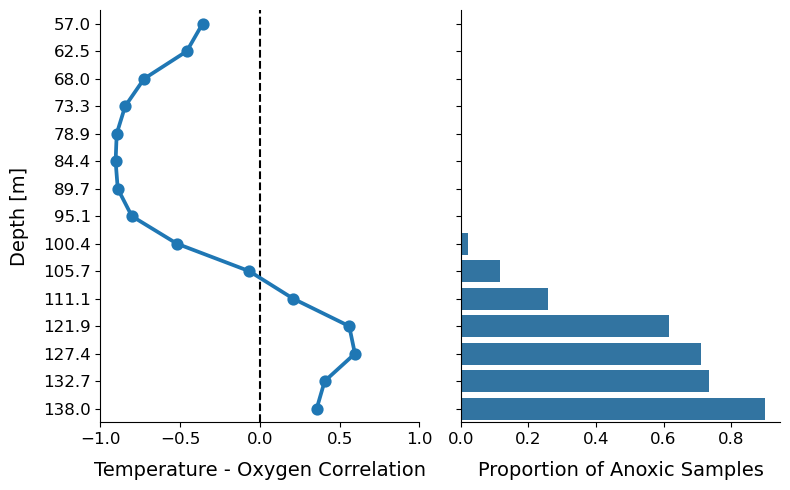

In [127]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

ax[0].axvline(0, color='black', linestyle='--')
sns.pointplot(res, x='r', y='depth', orient='y', ax=ax[0])

sns.barplot(res, x='prop_anoxia', y='depth', orient='y', ax=ax[1])

ax[0].set_xlabel('Temperature - Oxygen Correlation', fontsize=14, labelpad=10)
ax[1].set_xlabel('Proportion of Anoxic Samples', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    
ax[0].set_xlim(-1, 1)
#ax[0].grid(True)

plt.tight_layout()
plt.show()

### Interbasin flow spatial variability

In [18]:
ds_adcp_w = load_adcp(lake, year, date, 'LZW')
ds_adcp_c = load_adcp(lake, year, date, 'LZC')
ds_adcp_e = load_adcp(lake, year, date, 'LZE')

AttributeError: 'str' object has no attribute 'year'

In [209]:
d = 135
t0 = '2026-02-06'
tf = ds_adcp_e.time.values[-1]

vw = ds_adcp_w.vel.sel(dir='E', time=slice(t0, tf)).sel(depth=d, method='nearest')
vc = ds_adcp_c.vel.sel(dir='E', time=slice(t0, tf)).sel(depth=d, method='nearest')
ve = ds_adcp_e.vel.sel(dir='E', time=slice(t0, tf)).sel(depth=d, method='nearest')

window = 6
vw_ra = vw.rolling(time=window, center=True).mean()
vc_ra = vc.rolling(time=window, center=True).mean()
ve_ra = ve.rolling(time=window, center=True).mean()

<Axes: xlabel='time', ylabel='vel'>

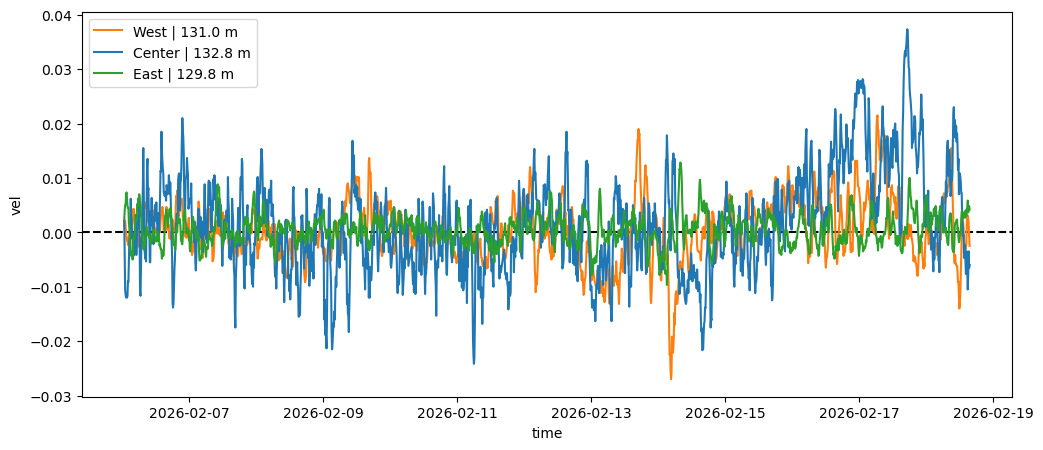

In [210]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0, color='black', linestyle='--')
sns.lineplot(x=vw_ra.time, y=vw_ra, color='tab:orange', ax=ax, label=f'West | {round(vw.depth.item(), 1)} m')
sns.lineplot(x=vc_ra.time, y=vc_ra, color='tab:blue', ax=ax, label=f'Center | {round(vc.depth.item(), 1)} m')
sns.lineplot(x=ve_ra.time, y=ve_ra, color='tab:green', ax=ax, label=f'East | {round(ve.depth.item(), 1)} m')

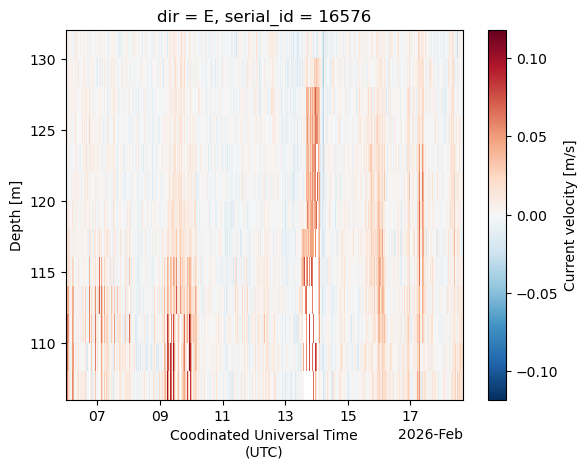

In [213]:
ds_adcp_w.sel(dir='E', time=slice(t0, tf)).vel.plot()

<Axes: xlabel='time', ylabel='vel'>

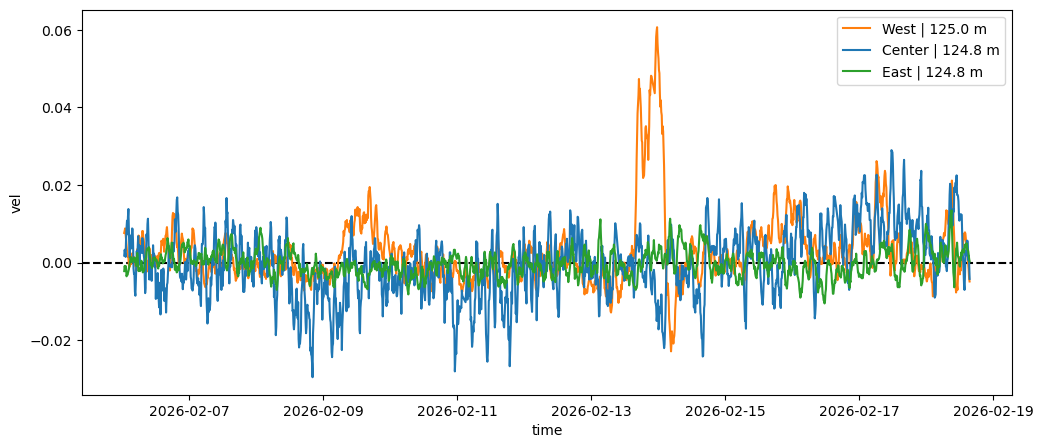

In [206]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0, color='black', linestyle='--')
sns.lineplot(x=vw_ra.time, y=vw_ra, color='tab:orange', ax=ax, label=f'West | {round(vw.depth.item(), 1)} m')
sns.lineplot(x=vc_ra.time, y=vc_ra, color='tab:blue', ax=ax, label=f'Center | {round(vc.depth.item(), 1)} m')
sns.lineplot(x=ve_ra.time, y=ve_ra, color='tab:green', ax=ax, label=f'East | {round(ve.depth.item(), 1)} m')

<Axes: xlabel='time', ylabel='vel'>

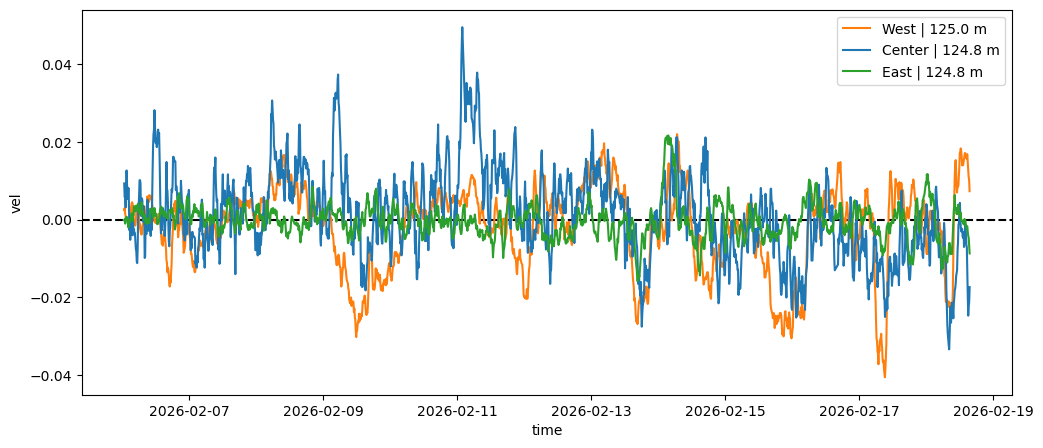

In [204]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.axhline(0, color='black', linestyle='--')
sns.lineplot(x=vw_ra.time, y=vw_ra, color='tab:orange', ax=ax, label=f'West | {round(vw.depth.item(), 1)} m')
sns.lineplot(x=vc_ra.time, y=vc_ra, color='tab:blue', ax=ax, label=f'Center | {round(vc.depth.item(), 1)} m')
sns.lineplot(x=ve_ra.time, y=ve_ra, color='tab:green', ax=ax, label=f'East | {round(ve.depth.item(), 1)} m')

In [199]:
scipy.stats.spearmanr(vw, vc, nan_policy='omit'), scipy.stats.spearmanr(vw, ve, nan_policy='omit'), scipy.stats.spearmanr(vw, vc, nan_policy='omit')

(SignificanceResult(statistic=np.float64(0.24612455551594542), pvalue=np.float64(1.6143565886145135e-26)),
 SignificanceResult(statistic=np.float64(0.13498171360799185), pvalue=np.float64(7.216595670957638e-09)),
 SignificanceResult(statistic=np.float64(0.24612455551594542), pvalue=np.float64(1.6143565886145135e-26)))

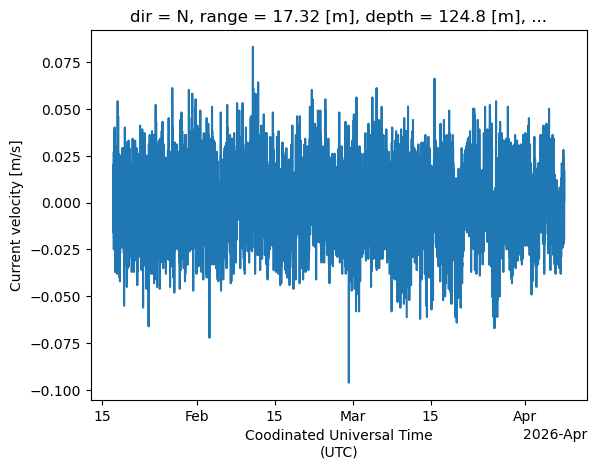

In [173]:
vc.plot()

In [153]:
mreader = ewg.mooring_reader.MooringReader(lake, year, date, 'LZC')
adcp = mreader.get_adcps()[-1]
areader = ewg.adcp_reader.ADCPReader(lake, year, date, 'LZC', adcp['serial_id'])
ds_adcp_c = areader.load()

In [154]:
ds_adcp_c

<xarray.Dataset> Size: 156MB
Dimensions:            (time: 12641, depth: 38, dir: 4, beam: 4, x: 4, x*: 4,
                        earth: 3, inst: 3)
Coordinates:
  * time               (time) datetime64[ns] 101kB 2026-01-15T15:17:11.028928...
  * dir                (dir) <U3 48B 'E' 'N' 'U' 'err'
    range              (depth) float64 304B ...
  * beam               (beam) int64 32B 1 2 3 4
  * x                  (x) int64 32B 1 2 3 4
  * x*                 (x*) int64 32B 1 2 3 4
  * earth              (earth) <U1 12B 'E' 'N' 'U'
  * inst               (inst) <U1 12B 'X' 'Y' 'Z'
  * depth              (depth) float64 304B 132.8 131.8 130.8 ... 96.78 95.78
    serial_id          <U5 20B ...
Data variables: (12/20)
    builtin_test_fail  (time, depth) float64 4MB ...
    c_sound            (time, depth) float32 2MB ...
    z                  (time, depth) float32 2MB ...
    pitch              (time, depth) float32 2MB ...
    roll               (time, depth) float32 2MB ...
    heading            (time, depth) float32 2MB ...
    ...                 ...
    vel                (dir, depth, time) float32 8MB ...
    amp                (beam, depth, time) float32 8MB ...
    corr               (beam, depth, time) float32 8MB ...
    prcnt_gd           (beam, depth, time) float32 8MB ...
    rotmat             (x, x*, time, depth) float64 61MB ...
    orientmat          (earth, inst, time, depth) float64 35MB ...
Attributes: (12/47)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.4
    inst_model:               Workhorse
    ...                       ...
    deployment:               16.01.2026
    retrieval:                09.04.2026
    sensor:                   adcp
    serial_id:                16549
    depth:                    142.10000610351562
    orientation:              up